# Multinomial naive bayes


In [7]:
# Import the required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import string
import matplotlib.pyplot as plt

#TSV dataset

In [8]:
data = pd.read_csv("spam.tsv",sep='\t',names=['Class','Message'])
data.head(8) # View the first 8 records of our dataset

,Class,Message
0,ham,I've been searching for the right words to tha...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,"Nah I don't think he goes to usf, he lives aro..."
3,ham,Even my brother is not like to speak with me. ...
4,ham,I HAVE A DATE ON SUNDAY WITH WILL!!!
5,ham,As per your request 'Melle Melle (Oru Minnamin...
6,spam,WINNER!! As a valued network customer you have...
7,spam,Had your mobile 11 months or more? U R entitle...


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5567 entries, 0 to 5566
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Class    5567 non-null   object
 1   Message  5567 non-null   object
dtypes: object(2)
memory usage: 87.1+ KB


In [10]:
data['Length'] = data['Message'].apply(len) # Create a new column 'Length' that contains the length of each message

In [11]:
data['Length']

0       196
1       155
2        61
3        77
4        36
       ... 
5562    160
5563     36
5564     57
5565    125
5566     26
Name: Length, Length: 5567, dtype: int64

In [12]:
data.groupby('Class').describe() # Group the data by 'Class' and describe the statistics of each group

Length                                                         
        count        mean        std   min    25%    50%    75%    max
Class                                                                 
ham    4821.0   71.442854  58.373866   2.0   33.0   52.0   93.0  910.0
spam    746.0  138.659517  28.891361  13.0  133.0  149.0  157.0  223.0

In [16]:
data['Length'].describe()

count    5567.000000
mean       80.450153
std        59.891023
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: Length, dtype: float64

Text(0, 0.5, 'Count')

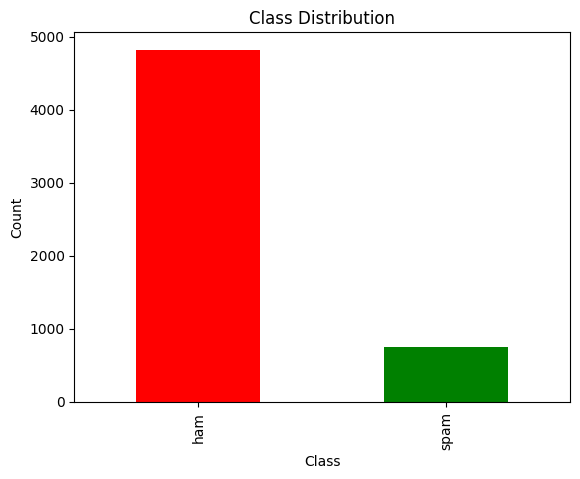

In [17]:
data['Class'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')


In [18]:
data.loc[data['Class']=="ham","Class"] = 1

In [19]:
data.loc[data['Class']=="spam","Class"] = 0

In [20]:
dObject2=data['Class'].values
dObject2

array([1, 0, 1, ..., 1, 1, 1], dtype=object)

In [21]:
import string
string

<module 'string' from 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\\Lib\\string.py'>

In [22]:
def remove_punctuation(text):
    text="".join([char for char in text if char not in string.punctuation])
    return text
data['text_clean'] = data['Message'].apply(lambda x: remove_punctuation(x)) # Remove punctuation from the 'Message' column
    

In [23]:
data.head() # View the first 8 records of our dataset after cleaning

,Class,Message,Length,text_clean
0,1,I've been searching for the right words to tha...,196,Ive been searching for the right words to than...
1,0,Free entry in 2 a wkly comp to win FA Cup fina...,155,Free entry in 2 a wkly comp to win FA Cup fina...
2,1,"Nah I don't think he goes to usf, he lives aro...",61,Nah I dont think he goes to usf he lives aroun...
3,1,Even my brother is not like to speak with me. ...,77,Even my brother is not like to speak with me T...
4,1,I HAVE A DATE ON SUNDAY WITH WILL!!!,36,I HAVE A DATE ON SUNDAY WITH WILL


In [24]:
CV = CountVectorizer(stop_words="english")

In [25]:
xSet = data['text_clean'].values
ySet = data['Class'].values
ySet

array([1, 0, 1, ..., 1, 1, 1], dtype=object)

In [32]:
# Datatype for y is object. lets convert it into int
ySet = ySet.astype('int')
ySet

array([1, 0, 1, ..., 1, 1, 1])

In [33]:
xSet

array(['Ive been searching for the right words to thank you for this breather I promise i wont take your help for granted and will fulfil my promise You have been wonderful and a blessing at all times',
       'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Text FA to 87121 to receive entry questionstd txt rateTCs apply 08452810075over18s',
       'Nah I dont think he goes to usf he lives around here though', ...,
       'Pity  was in mood for that Soany other suggestions',
       'The guy did some bitching but I acted like id be interested in buying something else next week and he gave it to us for free',
       'Rofl Its true to its name'], dtype=object)

In [34]:
xSet_train,xSet_test,ySet_train,ySet_test = train_test_split(xSet,ySet,test_size=0.2, random_state=10)

In [35]:
xSet_train_CV = CV.fit_transform(xSet_train)
xSet_train_CV

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 34532 stored elements and shape (4453, 8159)>

In [36]:
NB = MultinomialNB()


In [37]:
NB.fit(xSet_train_CV,ySet_train)

MultinomialNB()

In [38]:
xSet_test_CV = CV.transform(xSet_test)

In [39]:
ySet_predict = NB.predict(xSet_test_CV)
ySet_predict

array([1, 1, 1, ..., 1, 1, 1])

In [40]:
accuracyScore = accuracy_score(ySet_test,ySet_predict)

print("Prediction Accuracy :",accuracyScore)

Prediction Accuracy : 0.9829443447037702


In [41]:
msg = input("Enter Message: ") # to get the input message
msgInput = CV.transform([msg]) # 
predict = NB.predict(msgInput)
if(predict[0]==0):
    print("------------------------MESSAGE-SENT-[CHECK-SPAM-FOLDER]---------------------------")
else:
    print("---------------------------MESSAGE-SENT-[CHECK-INBOX]------------------------------")

---------------------------MESSAGE-SENT-[CHECK-INBOX]------------------------------


We cannot pass text directly to train our models in Natural Language Processing, thus we need to convert it into numbers, which machine can understand and can perform the required modelling on it

In [42]:
# creating a list of sentences
documents = ["Dog bites man.", "Man bites dog.", "Dog eats meat.", "Man eats food."]

# Changing the text to lower case and remove the full stop from text
processed_docs = [doc.lower().replace(".","") for doc in documents]
processed_docs

['dog bites man', 'man bites dog', 'dog eats meat', 'man eats food']

In [44]:
# corpus is the collection of text
#look at the documents list
print("Our corpus: ", processed_docs)

# Initialise the object for CountVectorizer
count_vect = CountVectorizer()

#Build a BOW representation for the corpus
bow_rep = count_vect.fit_transform(processed_docs)
# print(bow_rep)

#Look at the vocabulary mapping
print("Our vocabulary: ", count_vect.vocabulary_)

#see the BOW rep for first 2 documents
print("BoW representation for 'dog bites man': ", bow_rep[0].toarray())
print("BoW representation for 'man bites dog: ",bow_rep[1].toarray())

#Get the representation using this vocabulary, for a new text
temp = count_vect.transform(["dog and dog are friends"])
print("Bow representation for 'dog and dog are friends':", temp.toarray())

Our corpus:  ['dog bites man', 'man bites dog', 'dog eats meat', 'man eats food']
Our vocabulary:  {'dog': 1, 'bites': 0, 'man': 4, 'eats': 2, 'meat': 5, 'food': 3}
BoW representation for 'dog bites man':  [[1 1 0 0 1 0]]
BoW representation for 'man bites dog:  [[1 1 0 0 1 0]]
Bow representation for 'dog and dog are friends': [[0 2 0 0 0 0]]


In [45]:
X = data['text_clean'].values
y = data['Class'].values
y

array([1, 0, 1, ..., 1, 1, 1], dtype=object)

In [46]:
y = y.astype('int')
y

array([1, 0, 1, ..., 1, 1, 1])

In [47]:
## text preprocessing and feature vectorizer
# To extract features from a document of words, we import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tf=TfidfVectorizer() ## object creation
X=tf.fit_transform(X) ## fitting and transforming the data into vectors

In [48]:
tf.get_feature_names_out()

array(['008704050406', '0089my', '0121', ..., 'zyada', 'üll', '〨ud'],
      dtype=object)

In [49]:
X=X.toarray()

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=6)

In [51]:
## Model creation
from sklearn.naive_bayes import BernoulliNB

## model object creation
nb=BernoulliNB(alpha=0.01) 

## fitting the model
nb.fit(X_train,y_train)

## getting the prediction
y_hat=nb.predict(X_test) 

In [52]:
y_hat

array([1, 1, 1, ..., 1, 1, 1])

In [53]:
from sklearn.metrics import classification_report,confusion_matrix

In [54]:
print(classification_report(y_test,y_hat))
print(confusion_matrix(y_test,y_hat))
pd.crosstab(y_test,y_hat)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       186
           1       0.99      0.99      0.99      1206

    accuracy                           0.99      1392
   macro avg       0.98      0.98      0.98      1392
weighted avg       0.99      0.99      0.99      1392

[[ 178    8]
 [   7 1199]]


col_0,0,1
row_0,,
0,178,8
1,7,1199
